# 14 — Siamese Full-Train con Balanced Batch Sampling

Obiettivo: ripetere la migliore configurazione Siamese precedente usando **tutto il training set a 12 classi**, senza downsampling.

Configurazione congelata:
- FCGR k=6 (64x64)
- CNN V3 condivisa
- embedding 128D L2-normalizzato
- Euclidean Contrastive Loss, margin=1.25
- 3 epoche di random-pair warm-up
- Dynamic True Semi-Hard Negative Mining
- 6 negative candidates per anchor

Unica modifica sperimentale principale:
- prima: 2.111 campioni per classe tramite downsampling;
- ora: tutti i campioni disponibili vengono mantenuti;
- il training usa batch bilanciati rispetto alla classe dell'anchor.


In [1]:
# ============================================================
# CELL 1 — IMPORTS + FIXED CONFIG
# ============================================================

from pathlib import Path
import random
import time
import copy
import math

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "siamese_fulltrain_balanced"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = PROCESSED_DIR / "siamese_tumor_healthy_manifest.tsv"
CLASS_MAPPING_PATH = PROCESSED_DIR / "siamese_tumor_healthy_class_mapping.tsv"
VAL_POOL_PATH = PROCESSED_DIR / "siamese_val_pair_pool.tsv"

# IMPORTANT: k=6 is fixed explicitly.
K = 6
RANDOM_STATE = 42

FCGR_PATH = PROCESSED_DIR / "fcgr_cache" / "fcgr_k6.npy"
FCGR_INDEX_PATH = PROCESSED_DIR / "fcgr_cache" / "fcgr_k6_index.tsv"

N_CLASSES = 12
EMBEDDING_DIM = 128
EUCLIDEAN_MARGIN = 1.25

WARMUP_EPOCHS = 3
N_NEGATIVE_CANDIDATES = 6

# 60 = 5 anchors per class in every training batch.
BALANCED_BATCH_SIZE = 60
VAL_BATCH_SIZE = 128
VAL_PAIRS = 10_000

WARMUP_LR = 5e-4
SEMIHARD_LR = 1e-4
WEIGHT_DECAY = 1e-4

MAX_SEMIHARD_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 4
MIN_DELTA = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

print("Project:", PROJECT_ROOT)
print("Device:", DEVICE)
print("k:", K)
print("Balanced batch size:", BALANCED_BATCH_SIZE)
print("Margin:", EUCLIDEAN_MARGIN)


Project: D:\Daria\Desktop\eccdna_fcgr_siamese
Device: cuda
k: 6
Balanced batch size: 60
Margin: 1.25


In [2]:
# ============================================================
# CELL 2 — REPRODUCIBILITY
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)


Random seed: 42


In [3]:
# ============================================================
# CELL 3 — FULL 12-CLASS TRAINING SET (NO DOWNSAMPLING)
# ============================================================

metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    dtype={"id": str}
)

metadata["class_id"] = metadata["class_id"].astype(int)

train_metadata = (
    metadata[
        metadata["split_cluster"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

train_counts = (
    train_metadata["class_id"]
    .value_counts()
    .sort_index()
)

print("=" * 72)
print("FULL TRAIN DATA — NO DOWNSAMPLING")
print("=" * 72)

print("Training samples:", len(train_metadata))
print("Classes:", train_metadata["class_id"].nunique())
print()
print("Samples per class:")
print(train_counts)

assert train_metadata["class_id"].nunique() == N_CLASSES


FULL TRAIN DATA — NO DOWNSAMPLING
Training samples: 96167
Classes: 12

Samples per class:
class_id
0     10000
1     10000
2     10000
3     10000
4     10000
5     10000
6     10000
7     10000
8      5052
9      4880
10     4124
11     2111
Name: count, dtype: int64


In [4]:
# ============================================================
# CELL 4 — SAME VALIDATION SET AS PREVIOUS EXPERIMENT
# ============================================================

class_mapping = pd.read_csv(
    CLASS_MAPPING_PATH,
    sep="\t"
)

old_to_new = dict(
    zip(
        class_mapping["original_class_id"].astype(int),
        class_mapping["class_id"].astype(int)
    )
)

included_original_ids = set(old_to_new.keys())

val_original = pd.read_csv(
    VAL_POOL_PATH,
    sep="\t",
    dtype={"id": str}
)

val_original["class_id"] = val_original["class_id"].astype(int)

val_metadata = (
    val_original[
        val_original["class_id"].isin(included_original_ids)
    ]
    .copy()
    .reset_index(drop=True)
)

val_metadata["original_class_id"] = val_metadata["class_id"]

val_metadata["class_id"] = (
    val_metadata["original_class_id"]
    .map(old_to_new)
    .astype(int)
)

print("Validation samples:", len(val_metadata))
print("Validation classes:", val_metadata["class_id"].nunique())

assert val_metadata["class_id"].nunique() == N_CLASSES


Validation samples: 9753
Validation classes: 12


In [5]:
# ============================================================
# CELL 5 — LOAD FIXED k=6 FCGR CACHE
# ============================================================

fcgr_memmap = np.load(
    FCGR_PATH,
    mmap_mode="r"
)

fcgr_index = pd.read_csv(
    FCGR_INDEX_PATH,
    sep="\t",
    dtype={"id": str}
)

id_to_fcgr_row = dict(
    zip(
        fcgr_index["id"],
        fcgr_index["fcgr_row"]
    )
)

missing_train = (~train_metadata["id"].isin(id_to_fcgr_row)).sum()
missing_val = (~val_metadata["id"].isin(id_to_fcgr_row)).sum()

print("FCGR shape:", fcgr_memmap.shape)
print("FCGR dtype:", fcgr_memmap.dtype)
print("Missing train FCGR:", missing_train)
print("Missing validation FCGR:", missing_val)

assert fcgr_memmap.shape[1:] == (64, 64)
assert missing_train == 0
assert missing_val == 0


FCGR shape: (150272, 64, 64)
FCGR dtype: float32
Missing train FCGR: 0
Missing validation FCGR: 0


In [6]:
# ============================================================
# CELL 6 — BALANCED EPOCH SIZE
# ============================================================

# Warm-up: circa un pair constraint per training sample.
WARMUP_BATCHES_PER_EPOCH = math.ceil(
    len(train_metadata) / BALANCED_BATCH_SIZE
)

WARMUP_PAIRS_PER_EPOCH = (
    WARMUP_BATCHES_PER_EPOCH
    * BALANCED_BATCH_SIZE
)

# Semi-hard: ogni anchor produce 2 constraints:
# anchor-positive e anchor-negative.
# Scegliamo quindi circa metà degli anchor rispetto ai pair
# del warm-up, mantenendo un numero simile di constraints.
MINING_BATCHES_PER_EPOCH = math.ceil(
    (WARMUP_PAIRS_PER_EPOCH / 2)
    / BALANCED_BATCH_SIZE
)

MINING_ANCHORS_PER_EPOCH = (
    MINING_BATCHES_PER_EPOCH
    * BALANCED_BATCH_SIZE
)

print("=" * 72)
print("BALANCED TRAINING BUDGET")
print("=" * 72)

print("Full train samples:", len(train_metadata))
print("Warm-up batches/epoch:", WARMUP_BATCHES_PER_EPOCH)
print("Warm-up pairs/epoch:", WARMUP_PAIRS_PER_EPOCH)
print("Mining batches/epoch:", MINING_BATCHES_PER_EPOCH)
print("Mining anchors/epoch:", MINING_ANCHORS_PER_EPOCH)
print(
    "Semi-hard pair constraints/epoch:",
    2 * MINING_ANCHORS_PER_EPOCH
)


BALANCED TRAINING BUDGET
Full train samples: 96167
Warm-up batches/epoch: 1603
Warm-up pairs/epoch: 96180
Mining batches/epoch: 802
Mining anchors/epoch: 48120
Semi-hard pair constraints/epoch: 96240


In [7]:
# ============================================================
# CELL 7 — CNN ENCODER V3 (UNCHANGED)
# ============================================================

class FCGRCNNEncoderV3(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                32
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                32,
                3,
                padding=1,
                bias=False
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                64
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                128,
                128,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(
                (4, 4)
            )
        )


        self.embedding_head = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                256,
                embedding_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(x)

        z = self.embedding_head(x)


        return F.normalize(

            z,

            p=2,

            dim=1,

            eps=1e-8
        )


In [8]:
# ============================================================
# CELL 8 — SIAMESE V3 FROM SCRATCH (UNCHANGED)
# ============================================================

class SiameseV3(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.encoder = FCGRCNNEncoderV3(
            embedding_dim=embedding_dim
        )


    def forward(
        self,
        x1,
        x2
    ):

        batch_size = x1.shape[0]


        x = torch.cat(
            [x1, x2],
            dim=0
        )


        z = self.encoder(x)


        return (
            z[:batch_size],
            z[batch_size:]
        )


model = SiameseV3(
    embedding_dim=EMBEDDING_DIM
).to(DEVICE)


n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 72)
print("SIAMESE V3 — RANDOM INITIALIZATION")
print("=" * 72)

print(
    "Trainable parameters:",
    f"{n_params:,}"
)

print(
    "Pretrained checkpoint: NO"
)

print(
    "Training from scratch: YES"
)


SIAMESE V3 — RANDOM INITIALIZATION
Trainable parameters: 807,264
Pretrained checkpoint: NO
Training from scratch: YES


In [9]:
# ============================================================
# CELL 9 — STATIC RANDOM PAIRS FOR VALIDATION
# ============================================================

class RandomSiamesePairDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row,
        n_pairs,
        positive_fraction=0.5,
        seed=42
    ):
        self.metadata = metadata.copy().reset_index(drop=True)
        self.fcgr_memmap = fcgr_memmap
        self.n_pairs = int(n_pairs)
        self.positive_fraction = float(positive_fraction)
        self.seed = int(seed)

        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )

        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )

        self.classes = np.array(
            sorted(np.unique(self.labels)),
            dtype=np.int64
        )

        self.class_to_indices = {
            int(c): np.where(self.labels == c)[0]
            for c in self.classes
        }

        self._generate_pairs()

    def _generate_pairs(self):
        rng = np.random.default_rng(self.seed)

        n_positive = int(
            self.n_pairs * self.positive_fraction
        )

        targets = np.zeros(
            self.n_pairs,
            dtype=np.float32
        )
        targets[:n_positive] = 1.0
        rng.shuffle(targets)

        anchors = rng.integers(
            0,
            len(self.labels),
            size=self.n_pairs
        )

        partners = np.empty(
            self.n_pairs,
            dtype=np.int64
        )

        for i, anchor_idx in enumerate(anchors):

            anchor_idx = int(anchor_idx)
            anchor_class = int(self.labels[anchor_idx])

            if targets[i] == 1:
                candidates = self.class_to_indices[anchor_class]
                partner_idx = anchor_idx

                while partner_idx == anchor_idx:
                    partner_idx = int(
                        rng.choice(candidates)
                    )

            else:
                negative_classes = self.classes[
                    self.classes != anchor_class
                ]

                negative_class = int(
                    rng.choice(negative_classes)
                )

                partner_idx = int(
                    rng.choice(
                        self.class_to_indices[negative_class]
                    )
                )

            partners[i] = partner_idx

        self.row1 = self.rows[anchors]
        self.row2 = self.rows[partners]
        self.targets = targets

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, index):
        x1 = np.array(
            self.fcgr_memmap[int(self.row1[index])],
            dtype=np.float32,
            copy=True
        )

        x2 = np.array(
            self.fcgr_memmap[int(self.row2[index])],
            dtype=np.float32,
            copy=True
        )

        return {
            "x1": torch.from_numpy(x1).unsqueeze(0),
            "x2": torch.from_numpy(x2).unsqueeze(0),
            "target": torch.tensor(
                self.targets[index],
                dtype=torch.float32
            )
        }


In [10]:
# ============================================================
# CELL 10 — BALANCED PAIRS FOR RANDOM WARM-UP
# ============================================================

class BalancedSiamesePairDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row,
        n_batches,
        batch_size=60,
        positive_fraction=0.50,
        seed=42
    ):
        self.metadata = metadata.copy().reset_index(drop=True)
        self.fcgr_memmap = fcgr_memmap
        self.n_batches = int(n_batches)
        self.batch_size = int(batch_size)
        self.positive_fraction = float(positive_fraction)
        self.seed = int(seed)

        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )

        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )

        self.classes = np.array(
            sorted(np.unique(self.labels)),
            dtype=np.int64
        )

        self.n_classes = len(self.classes)

        if self.batch_size % self.n_classes != 0:
            raise ValueError(
                "batch_size must be divisible by number of classes"
            )

        self.samples_per_class_per_batch = (
            self.batch_size // self.n_classes
        )

        self.class_to_indices = {
            int(c): np.where(self.labels == c)[0]
            for c in self.classes
        }

        self.n_pairs = (
            self.n_batches * self.batch_size
        )

        self.set_epoch(0)

    def set_epoch(self, epoch):
        rng = np.random.default_rng(
            self.seed + int(epoch) * 100_003
        )

        row1 = []
        row2 = []
        targets_all = []
        anchor_classes_all = []

        positives_per_batch = int(
            round(
                self.batch_size
                * self.positive_fraction
            )
        )

        for _ in range(self.n_batches):

            anchor_classes = np.repeat(
                self.classes,
                self.samples_per_class_per_batch
            )
            rng.shuffle(anchor_classes)

            targets = np.zeros(
                self.batch_size,
                dtype=np.float32
            )
            targets[:positives_per_batch] = 1.0
            rng.shuffle(targets)

            for anchor_class, target in zip(
                anchor_classes,
                targets
            ):
                anchor_class = int(anchor_class)

                anchor_idx = int(
                    rng.choice(
                        self.class_to_indices[anchor_class]
                    )
                )

                if target == 1.0:
                    candidates = (
                        self.class_to_indices[anchor_class]
                    )

                    partner_idx = anchor_idx

                    while partner_idx == anchor_idx:
                        partner_idx = int(
                            rng.choice(candidates)
                        )

                else:
                    negative_classes = self.classes[
                        self.classes != anchor_class
                    ]

                    negative_class = int(
                        rng.choice(negative_classes)
                    )

                    partner_idx = int(
                        rng.choice(
                            self.class_to_indices[
                                negative_class
                            ]
                        )
                    )

                row1.append(
                    int(self.rows[anchor_idx])
                )
                row2.append(
                    int(self.rows[partner_idx])
                )
                targets_all.append(
                    float(target)
                )
                anchor_classes_all.append(
                    anchor_class
                )

        self.row1 = np.asarray(
            row1,
            dtype=np.int64
        )
        self.row2 = np.asarray(
            row2,
            dtype=np.int64
        )
        self.targets = np.asarray(
            targets_all,
            dtype=np.float32
        )
        self.anchor_classes = np.asarray(
            anchor_classes_all,
            dtype=np.int64
        )

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, index):
        x1 = np.array(
            self.fcgr_memmap[int(self.row1[index])],
            dtype=np.float32,
            copy=True
        )

        x2 = np.array(
            self.fcgr_memmap[int(self.row2[index])],
            dtype=np.float32,
            copy=True
        )

        return {
            "x1": torch.from_numpy(x1).unsqueeze(0),
            "x2": torch.from_numpy(x2).unsqueeze(0),
            "target": torch.tensor(
                self.targets[index],
                dtype=torch.float32
            )
        }


In [11]:
# ============================================================
# CELL 11 — BALANCED SEMI-HARD CANDIDATE DATASET
# ============================================================

class BalancedSemiHardCandidateDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row,
        n_batches,
        batch_size=60,
        n_negative_candidates=6,
        seed=42
    ):
        self.metadata = metadata.copy().reset_index(drop=True)
        self.fcgr_memmap = fcgr_memmap
        self.n_batches = int(n_batches)
        self.batch_size = int(batch_size)
        self.n_negative_candidates = int(
            n_negative_candidates
        )
        self.seed = int(seed)

        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )

        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )

        self.classes = np.array(
            sorted(np.unique(self.labels)),
            dtype=np.int64
        )

        self.n_classes = len(self.classes)

        if self.batch_size % self.n_classes != 0:
            raise ValueError(
                "batch_size must be divisible by number of classes"
            )

        self.samples_per_class_per_batch = (
            self.batch_size // self.n_classes
        )

        self.class_to_indices = {
            int(c): np.where(self.labels == c)[0]
            for c in self.classes
        }

        self.n_anchors = (
            self.n_batches
            * self.batch_size
        )

        self.set_epoch(0)

    def set_epoch(self, epoch):
        rng = np.random.default_rng(
            self.seed + int(epoch) * 100_003
        )

        anchor_indices = []
        positive_indices = []
        negative_indices = []
        anchor_classes_all = []

        for _ in range(self.n_batches):

            anchor_classes = np.repeat(
                self.classes,
                self.samples_per_class_per_batch
            )

            rng.shuffle(anchor_classes)

            for anchor_class in anchor_classes:

                anchor_class = int(anchor_class)

                anchor_idx = int(
                    rng.choice(
                        self.class_to_indices[
                            anchor_class
                        ]
                    )
                )

                positive_candidates = (
                    self.class_to_indices[
                        anchor_class
                    ]
                )

                positive_idx = anchor_idx

                while positive_idx == anchor_idx:
                    positive_idx = int(
                        rng.choice(
                            positive_candidates
                        )
                    )

                negative_classes = self.classes[
                    self.classes != anchor_class
                ]

                selected_classes = rng.choice(
                    negative_classes,
                    size=self.n_negative_candidates,
                    replace=(
                        self.n_negative_candidates
                        >
                        len(negative_classes)
                    )
                )

                selected_negatives = [
                    int(
                        rng.choice(
                            self.class_to_indices[
                                int(negative_class)
                            ]
                        )
                    )
                    for negative_class
                    in selected_classes
                ]

                anchor_indices.append(anchor_idx)
                positive_indices.append(positive_idx)
                negative_indices.append(
                    selected_negatives
                )
                anchor_classes_all.append(
                    anchor_class
                )

        self.anchor_indices = np.asarray(
            anchor_indices,
            dtype=np.int64
        )

        self.positive_indices = np.asarray(
            positive_indices,
            dtype=np.int64
        )

        self.negative_indices = np.asarray(
            negative_indices,
            dtype=np.int64
        )

        self.anchor_classes = np.asarray(
            anchor_classes_all,
            dtype=np.int64
        )

    def __len__(self):
        return self.n_anchors

    def __getitem__(self, index):

        anchor_idx = int(
            self.anchor_indices[index]
        )

        positive_idx = int(
            self.positive_indices[index]
        )

        anchor = np.array(
            self.fcgr_memmap[
                int(self.rows[anchor_idx])
            ],
            dtype=np.float32,
            copy=True
        )

        positive = np.array(
            self.fcgr_memmap[
                int(self.rows[positive_idx])
            ],
            dtype=np.float32,
            copy=True
        )

        negatives = []

        for negative_idx in self.negative_indices[index]:

            negative = np.array(
                self.fcgr_memmap[
                    int(
                        self.rows[
                            int(negative_idx)
                        ]
                    )
                ],
                dtype=np.float32,
                copy=True
            )

            negatives.append(negative)

        negatives = np.stack(
            negatives,
            axis=0
        )

        return {
            "anchor": torch.from_numpy(anchor).unsqueeze(0),
            "positive": torch.from_numpy(positive).unsqueeze(0),
            "negatives": torch.from_numpy(negatives).unsqueeze(1)
        }


In [12]:
# ============================================================
# CELL 12 — DATASETS + LOADERS
# ============================================================

warmup_train_dataset = BalancedSiamesePairDataset(
    metadata=train_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row,
    n_batches=WARMUP_BATCHES_PER_EPOCH,
    batch_size=BALANCED_BATCH_SIZE,
    positive_fraction=0.50,
    seed=RANDOM_STATE
)

val_pair_dataset = RandomSiamesePairDataset(
    metadata=val_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row,
    n_pairs=VAL_PAIRS,
    positive_fraction=0.50,
    seed=RANDOM_STATE + 50_000
)

mining_dataset = BalancedSemiHardCandidateDataset(
    metadata=train_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row,
    n_batches=MINING_BATCHES_PER_EPOCH,
    batch_size=BALANCED_BATCH_SIZE,
    n_negative_candidates=N_NEGATIVE_CANDIDATES,
    seed=RANDOM_STATE
)

warmup_train_loader = DataLoader(
    warmup_train_dataset,
    batch_size=BALANCED_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=AMP_ENABLED
)

val_pair_loader = DataLoader(
    val_pair_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=AMP_ENABLED
)

mining_loader = DataLoader(
    mining_dataset,
    batch_size=BALANCED_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=AMP_ENABLED
)

print("Warm-up pairs:", len(warmup_train_dataset))
print("Validation pairs:", len(val_pair_dataset))
print("Mining anchors:", len(mining_dataset))
print(
    "Negative candidates/anchor:",
    N_NEGATIVE_CANDIDATES
)


Warm-up pairs: 96180
Validation pairs: 10000
Mining anchors: 48120
Negative candidates/anchor: 6


In [13]:
# ============================================================
# CELL 13 — VERIFY BALANCED BATCH SAMPLING
# ============================================================

warmup_train_dataset.set_epoch(0)
mining_dataset.set_epoch(0)

first_warmup_classes = (
    warmup_train_dataset.anchor_classes[
        :BALANCED_BATCH_SIZE
    ]
)

first_mining_classes = (
    mining_dataset.anchor_classes[
        :BALANCED_BATCH_SIZE
    ]
)

warmup_counts = pd.Series(
    first_warmup_classes
).value_counts().sort_index()

mining_counts = pd.Series(
    first_mining_classes
).value_counts().sort_index()

print("=" * 72)
print("FIRST BALANCED WARM-UP BATCH — ANCHOR CLASS COUNTS")
print("=" * 72)
print(warmup_counts)

print()
print("=" * 72)
print("FIRST BALANCED MINING BATCH — ANCHOR CLASS COUNTS")
print("=" * 72)
print(mining_counts)

print()
print(
    "Warm-up positive fraction:",
    warmup_train_dataset.targets[
        :BALANCED_BATCH_SIZE
    ].mean()
)

assert np.all(
    warmup_counts.values
    ==
    BALANCED_BATCH_SIZE // N_CLASSES
)

assert np.all(
    mining_counts.values
    ==
    BALANCED_BATCH_SIZE // N_CLASSES
)


FIRST BALANCED WARM-UP BATCH — ANCHOR CLASS COUNTS
0     5
1     5
2     5
3     5
4     5
5     5
6     5
7     5
8     5
9     5
10    5
11    5
Name: count, dtype: int64

FIRST BALANCED MINING BATCH — ANCHOR CLASS COUNTS
0     5
1     5
2     5
3     5
4     5
5     5
6     5
7     5
8     5
9     5
10    5
11    5
Name: count, dtype: int64

Warm-up positive fraction: 0.5


In [14]:
# ============================================================
# CELL 14 — EUCLIDEAN CONTRASTIVE LOSS
# ============================================================

class EuclideanContrastiveLoss(nn.Module):

    def __init__(
        self,
        margin=1.25
    ):

        super().__init__()

        self.margin = float(
            margin
        )


    def forward(
        self,
        z1,
        z2,
        target
    ):

        z1 = z1.float()

        z2 = z2.float()

        target = target.float()


        distances = torch.linalg.vector_norm(

            z1 - z2,

            ord=2,

            dim=1
        )


        positive_loss = (
            target
            *
            distances.pow(2)
        )


        negative_loss = (

            (1.0 - target)

            *

            F.relu(
                self.margin
                -
                distances
            ).pow(2)
        )


        loss = (
            positive_loss
            +
            negative_loss
        ).mean()


        return (
            loss,
            distances
        )


criterion = EuclideanContrastiveLoss(

    margin=
        EUCLIDEAN_MARGIN
)


In [15]:
# ============================================================
# CELL 15 — PAIRWISE EVALUATION
# ============================================================

def evaluate_pairwise(
    model,
    loader,
    criterion
):

    model.eval()


    total_loss = 0.0
    total_samples = 0

    all_targets = []
    all_distances = []


    with torch.no_grad():

        for batch in loader:

            x1 = (
                batch["x1"]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )

            x2 = (
                batch["x2"]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )

            target = (
                batch["target"]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )


            with torch.autocast(

                device_type=
                    DEVICE.type,

                dtype=(
                    torch.float16
                    if DEVICE.type == "cuda"
                    else torch.bfloat16
                ),

                enabled=
                    AMP_ENABLED
            ):

                z1, z2 = model(
                    x1,
                    x2
                )


            loss, distances = criterion(

                z1,
                z2,
                target
            )


            batch_size = (
                target.shape[0]
            )


            total_loss += (
                loss.item()
                *
                batch_size
            )

            total_samples += (
                batch_size
            )


            all_targets.append(

                target
                .cpu()
                .numpy()
            )

            all_distances.append(

                distances
                .cpu()
                .numpy()
            )


    targets = np.concatenate(
        all_targets
    )

    distances = np.concatenate(
        all_distances
    )


    positive_distances = (
        distances[
            targets == 1
        ]
    )

    negative_distances = (
        distances[
            targets == 0
        ]
    )


    d_pos = float(
        positive_distances.mean()
    )

    d_neg = float(
        negative_distances.mean()
    )


    gap = (
        d_neg
        -
        d_pos
    )


    pooled_variance = (
        0.5
        *
        (
            positive_distances.var()
            +
            negative_distances.var()
        )
    )


    d_prime = float(

        gap

        /

        np.sqrt(
            pooled_variance
            +
            1e-12
        )
    )


    auc = float(

        roc_auc_score(

            targets,

            -distances
        )
    )


    return {

        "loss":
            total_loss
            /
            total_samples,

        "auc":
            auc,

        "d_pos":
            d_pos,

        "d_neg":
            d_neg,

        "gap":
            gap,

        "d_prime":
            d_prime
    }


In [16]:
# ============================================================
# CELL 16 — RANDOM WARM-UP EPOCH
# ============================================================

def train_random_epoch(
    model,
    loader,
    dataset,
    criterion,
    optimizer,
    scaler,
    epoch
):

    model.train()

    dataset.set_epoch(
        epoch
    )


    total_loss = 0.0
    total_samples = 0

    all_targets = []
    all_distances = []


    start_time = time.perf_counter()


    for batch in loader:

        x1 = batch["x1"].to(
            DEVICE,
            non_blocking=True
        )

        x2 = batch["x2"].to(
            DEVICE,
            non_blocking=True
        )

        target = batch["target"].to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=(
                torch.float16
                if DEVICE.type == "cuda"
                else torch.bfloat16
            ),

            enabled=AMP_ENABLED
        ):

            z1, z2 = model(
                x1,
                x2
            )


        loss, distances = criterion(
            z1,
            z2,
            target
        )


        if AMP_ENABLED:

            scaler.scale(
                loss
            ).backward()

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            loss.backward()

            optimizer.step()


        batch_size_now = (
            target.shape[0]
        )


        total_loss += (
            loss.item()
            *
            batch_size_now
        )

        total_samples += (
            batch_size_now
        )


        all_targets.append(
            target.detach().cpu().numpy()
        )

        all_distances.append(
            distances.detach().cpu().numpy()
        )


    targets = np.concatenate(
        all_targets
    )

    distances = np.concatenate(
        all_distances
    )


    positive = distances[
        targets == 1
    ]

    negative = distances[
        targets == 0
    ]


    return {

        "loss":
            total_loss
            /
            total_samples,

        "auc":
            float(
                roc_auc_score(
                    targets,
                    -distances
                )
            ),

        "d_pos":
            float(
                positive.mean()
            ),

        "d_neg":
            float(
                negative.mean()
            ),

        "gap":
            float(
                negative.mean()
                -
                positive.mean()
            ),

        "seconds":
            time.perf_counter()
            -
            start_time
    }


In [17]:
# ============================================================
# CELL 17 — DYNAMIC TRUE SEMI-HARD NEGATIVE SELECTION
# ============================================================

@torch.no_grad()
def select_semihard_negatives(
    model,
    anchor,
    positive,
    negatives,
    margin
):

    model.eval()

    batch_size = anchor.shape[0]

    n_candidates = negatives.shape[1]


    # negatives:
    # [B, K, 1, 64, 64]

    negatives_flat = negatives.reshape(

        batch_size * n_candidates,

        *negatives.shape[2:]
    )


    # ========================================================
    # EMBEDDING CON IL MODELLO CORRENTE
    # ========================================================

    all_images = torch.cat(

        [
            anchor,
            positive,
            negatives_flat
        ],

        dim=0
    )


    with torch.autocast(

        device_type=DEVICE.type,

        dtype=(
            torch.float16
            if DEVICE.type == "cuda"
            else torch.bfloat16
        ),

        enabled=AMP_ENABLED
    ):

        all_embeddings = model.encoder(
            all_images
        )


    z_anchor = (
        all_embeddings[
            :batch_size
        ]
        .float()
    )

    z_positive = (
        all_embeddings[
            batch_size:
            2 * batch_size
        ]
        .float()
    )

    z_negatives = (

        all_embeddings[
            2 * batch_size:
        ]

        .float()

        .reshape(
            batch_size,
            n_candidates,
            -1
        )
    )


    # ========================================================
    # DISTANCES
    # ========================================================

    d_pos = torch.linalg.vector_norm(

        z_anchor
        -
        z_positive,

        ord=2,

        dim=1
    )


    d_neg = torch.linalg.vector_norm(

        z_anchor[:, None, :]
        -
        z_negatives,

        ord=2,

        dim=2
    )


    # ========================================================
    # TRUE SEMI-HARD:
    #
    # d_pos < d_neg < margin
    # ========================================================

    semihard_mask = (

        (d_neg > d_pos[:, None])

        &

        (d_neg < margin)
    )


    has_semihard = (
        semihard_mask.any(
            dim=1
        )
    )


    # ========================================================
    # SEMI-HARD SELECTION
    #
    # scegliamo la più vicina tra quelle valide
    # ========================================================

    masked_distances = torch.where(

        semihard_mask,

        d_neg,

        torch.full_like(
            d_neg,
            float("inf")
        )
    )


    semihard_indices = (
        masked_distances
        .argmin(dim=1)
    )


    # ========================================================
    # FALLBACK
    #
    # Caso 1:
    # esiste una negative > positive ma fuori dal margin.
    #
    # prendiamo quella più vicina.
    #
    # Caso 2:
    # tutte le negative sono più vicine del positive.
    #
    # prendiamo la PIÙ LONTANA, quindi la meno aggressiva.
    # ========================================================

    safer_mask = (
        d_neg
        >
        d_pos[:, None]
    )


    safer_distances = torch.where(

        safer_mask,

        d_neg,

        torch.full_like(
            d_neg,
            float("inf")
        )
    )


    safer_indices = (
        safer_distances
        .argmin(dim=1)
    )


    has_safer = (
        safer_mask.any(
            dim=1
        )
    )


    least_hard_indices = (
        d_neg.argmax(
            dim=1
        )
    )


    fallback_indices = torch.where(

        has_safer,

        safer_indices,

        least_hard_indices
    )


    selected_indices = torch.where(

        has_semihard,

        semihard_indices,

        fallback_indices
    )


    batch_indices = torch.arange(

        batch_size,

        device=negatives.device
    )


    selected_negatives = negatives[

        batch_indices,

        selected_indices
    ]


    selected_distances = d_neg[

        batch_indices,

        selected_indices
    ]


    stats = {

        "semihard_fraction":
            has_semihard.float().mean().item(),

        "fallback_fraction":
            (~has_semihard).float().mean().item(),

        "mean_d_pos":
            d_pos.mean().item(),

        "mean_selected_d_neg":
            selected_distances.mean().item(),

        "selected_valid_fraction":
            (
                selected_distances
                >
                d_pos
            )
            .float()
            .mean()
            .item(),

        "selected_inside_margin_fraction":
            (
                selected_distances
                <
                margin
            )
            .float()
            .mean()
            .item()
    }


    return (
        selected_negatives,
        stats
    )


In [18]:
# ============================================================
# CELL 18 — TRAIN ONE DYNAMIC SEMI-HARD EPOCH
# ============================================================

def train_dynamic_semihard_epoch(
    model,
    loader,
    dataset,
    criterion,
    optimizer,
    scaler,
    epoch
):

    dataset.set_epoch(
        epoch
    )


    total_loss = 0.0

    total_samples = 0

    all_targets = []
    all_distances = []


    semihard_fractions = []

    selected_valid_fractions = []

    mean_selected_negative_distances = []


    start_time = time.perf_counter()


    for batch in loader:

        anchor = (
            batch["anchor"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        positive = (
            batch["positive"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        negatives = (
            batch["negatives"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        # ====================================================
        # 1. MINING SENZA GRADIENTE
        # ====================================================

        selected_negative, mining_stats = (
            select_semihard_negatives(

                model=model,

                anchor=anchor,

                positive=positive,

                negatives=negatives,

                margin=EUCLIDEAN_MARGIN
            )
        )


        # ====================================================
        # 2. TRAINING SULLE COPPIE SELEZIONATE
        # ====================================================

        model.train()


        optimizer.zero_grad(
            set_to_none=True
        )


        batch_size_now = (
            anchor.shape[0]
        )


        # Un unico forward:
        #
        # anchor
        # positive
        # selected negative

        train_images = torch.cat(

            [
                anchor,
                positive,
                selected_negative
            ],

            dim=0
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=(
                torch.float16
                if DEVICE.type == "cuda"
                else torch.bfloat16
            ),

            enabled=AMP_ENABLED
        ):

            embeddings = model.encoder(
                train_images
            )


        z_anchor = embeddings[
            :batch_size_now
        ]

        z_positive = embeddings[
            batch_size_now:
            2 * batch_size_now
        ]

        z_negative = embeddings[
            2 * batch_size_now:
        ]


        # ====================================================
        # COSTRUIAMO 2B PAIRS:
        #
        # anchor-positive target=1
        # anchor-negative target=0
        # ====================================================

        z1 = torch.cat(

            [
                z_anchor,
                z_anchor
            ],

            dim=0
        )


        z2 = torch.cat(

            [
                z_positive,
                z_negative
            ],

            dim=0
        )


        targets = torch.cat(

            [
                torch.ones(
                    batch_size_now,
                    device=DEVICE
                ),

                torch.zeros(
                    batch_size_now,
                    device=DEVICE
                )
            ],

            dim=0
        )


        loss, distances = criterion(

            z1,
            z2,
            targets
        )


        # ====================================================
        # BACKPROP
        # ====================================================

        if AMP_ENABLED:

            scaler.scale(
                loss
            ).backward()

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            loss.backward()

            optimizer.step()


        n_pair_constraints = (
            targets.shape[0]
        )


        total_loss += (
            loss.detach().item()
            *
            n_pair_constraints
        )


        total_samples += (
            n_pair_constraints
        )


        all_targets.append(

            targets.detach()
            .cpu()
            .numpy()
        )


        all_distances.append(

            distances.detach()
            .cpu()
            .numpy()
        )


        semihard_fractions.append(

            mining_stats[
                "semihard_fraction"
            ]
        )


        selected_valid_fractions.append(

            mining_stats[
                "selected_valid_fraction"
            ]
        )


        mean_selected_negative_distances.append(

            mining_stats[
                "mean_selected_d_neg"
            ]
        )


    # ========================================================
    # EPOCH METRICS
    # ========================================================

    targets_np = np.concatenate(
        all_targets
    )


    distances_np = np.concatenate(
        all_distances
    )


    positive_distances = (
        distances_np[
            targets_np == 1
        ]
    )


    negative_distances = (
        distances_np[
            targets_np == 0
        ]
    )


    train_auc = float(

        roc_auc_score(
            targets_np,
            -distances_np
        )
    )


    return {

        "loss":
            total_loss
            /
            total_samples,

        "auc":
            train_auc,

        "d_pos":
            float(
                positive_distances.mean()
            ),

        "d_neg":
            float(
                negative_distances.mean()
            ),

        "gap":
            float(
                negative_distances.mean()
                -
                positive_distances.mean()
            ),

        "semihard_fraction":
            float(
                np.mean(
                    semihard_fractions
                )
            ),

        "valid_negative_fraction":
            float(
                np.mean(
                    selected_valid_fractions
                )
            ),

        "selected_d_neg":
            float(
                np.mean(
                    mean_selected_negative_distances
                )
            ),

        "seconds":
            time.perf_counter()
            -
            start_time
    }


In [19]:
# ============================================================
# CELL 19 — SANITY CHECK BEFORE TRAINING
# ============================================================

print("=" * 80)
print("FULL-TRAIN BALANCED — SANITY CHECK")
print("=" * 80)

warmup_batch = next(iter(warmup_train_loader))

x1 = warmup_batch["x1"].to(DEVICE)
x2 = warmup_batch["x2"].to(DEVICE)
target = warmup_batch["target"].to(DEVICE)

with torch.no_grad():
    z1, z2 = model(x1, x2)
    sanity_loss, sanity_distances = criterion(
        z1,
        z2,
        target
    )

print("x1:", tuple(x1.shape))
print("z1:", tuple(z1.shape))
print("Mean embedding norm:", z1.norm(dim=1).mean().item())
print("Initial contrastive loss:", sanity_loss.item())
print("Finite embeddings:", torch.isfinite(z1).all().item())

mining_batch = next(iter(mining_loader))

anchor = mining_batch["anchor"].to(DEVICE)
positive = mining_batch["positive"].to(DEVICE)
negatives = mining_batch["negatives"].to(DEVICE)

selected_negative, mining_stats = select_semihard_negatives(
    model=model,
    anchor=anchor,
    positive=positive,
    negatives=negatives,
    margin=EUCLIDEAN_MARGIN
)

print()
print("Mining batch anchor:", tuple(anchor.shape))
print("Mining candidates:", tuple(negatives.shape))
print("Selected negative:", tuple(selected_negative.shape))
print("Initial mining stats:")
print(mining_stats)


FULL-TRAIN BALANCED — SANITY CHECK
x1: (60, 1, 64, 64)
z1: (60, 128)
Mean embedding norm: 1.0
Initial contrastive loss: 0.48588889837265015
Finite embeddings: True

Mining batch anchor: (60, 1, 64, 64)
Mining candidates: (60, 6, 1, 64, 64)
Selected negative: (60, 1, 64, 64)
Initial mining stats:
{'semihard_fraction': 0.9500000476837158, 'fallback_fraction': 0.05000000447034836, 'mean_d_pos': 0.2906709611415863, 'mean_selected_d_neg': 0.3115096390247345, 'selected_valid_fraction': 0.9500000476837158, 'selected_inside_margin_fraction': 1.0}


In [20]:
# ============================================================
# CELL 20 — RANDOM-PAIR WARM-UP FROM SCRATCH
# ============================================================

# Reinitialize explicitly before the real experiment.
set_seed(RANDOM_STATE)

model = SiameseV3(
    embedding_dim=EMBEDDING_DIM
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=WARMUP_LR,
    weight_decay=WEIGHT_DECAY
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED
)

warmup_history = []

print("=" * 110)
print("FULL-TRAIN BALANCED SIAMESE — RANDOM WARM-UP")
print("=" * 110)

for epoch in range(1, WARMUP_EPOCHS + 1):

    train_metrics = train_random_epoch(
        model=model,
        loader=warmup_train_loader,
        dataset=warmup_train_dataset,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        epoch=epoch
    )

    val_metrics = evaluate_pairwise(
        model=model,
        loader=val_pair_loader,
        criterion=criterion
    )

    warmup_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_auc": train_metrics["auc"],
        "val_loss": val_metrics["loss"],
        "val_auc": val_metrics["auc"],
        "val_d_pos": val_metrics["d_pos"],
        "val_d_neg": val_metrics["d_neg"],
        "val_gap": val_metrics["gap"],
        "val_d_prime": val_metrics["d_prime"],
        "seconds": train_metrics["seconds"]
    })

    print(
        f"Warm-up {epoch:02d}/{WARMUP_EPOCHS}"
        f" | train AUC {train_metrics['auc']:.4f}"
        f" | val AUC {val_metrics['auc']:.4f}"
        f" | d+ {val_metrics['d_pos']:.4f}"
        f" | d- {val_metrics['d_neg']:.4f}"
        f" | gap {val_metrics['gap']:.4f}"
        f" | d' {val_metrics['d_prime']:.4f}"
        f" | {train_metrics['seconds']:.1f}s"
    )

post_warmup_state = copy.deepcopy(
    model.state_dict()
)

pd.DataFrame(
    warmup_history
).to_csv(
    ARTIFACTS_DIR / "fulltrain_balanced_warmup_history.tsv",
    sep="\t",
    index=False
)

print("Post-warmup state saved in memory.")


FULL-TRAIN BALANCED SIAMESE — RANDOM WARM-UP
Warm-up 01/3 | train AUC 0.6244 | val AUC 0.6353 | d+ 0.5630 | d- 0.6566 | gap 0.0937 | d' 0.4825 | 55.8s
Warm-up 02/3 | train AUC 0.6428 | val AUC 0.6456 | d+ 0.5587 | d- 0.6613 | gap 0.1026 | d' 0.5293 | 162.7s
Warm-up 03/3 | train AUC 0.6573 | val AUC 0.6488 | d+ 0.6023 | d- 0.7033 | gap 0.1010 | d' 0.5303 | 73.6s
Post-warmup state saved in memory.


In [26]:
# ============================================================
# POST-WARMUP — SEMI-HARD MINING CHECK
# ============================================================

# Generiamo un batch fresco per la fase successiva
mining_dataset.set_epoch(
    WARMUP_EPOCHS + 1
)

mining_batch = next(
    iter(mining_loader)
)

anchor = (
    mining_batch["anchor"]
    .to(
        DEVICE,
        non_blocking=True
    )
)

positive = (
    mining_batch["positive"]
    .to(
        DEVICE,
        non_blocking=True
    )
)

negatives = (
    mining_batch["negatives"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


selected_negative, post_warmup_mining_stats = (
    select_semihard_negatives(
        model=model,
        anchor=anchor,
        positive=positive,
        negatives=negatives,
        margin=EUCLIDEAN_MARGIN
    )
)


post_warmup_val_metrics = evaluate_pairwise(
    model=model,
    loader=val_pair_loader,
    criterion=criterion
)


print("=" * 80)
print("POST-WARMUP CHECK")
print("=" * 80)

print()
print("VALIDATION:")
print(
    "ROC-AUC:",
    f"{post_warmup_val_metrics['auc']:.6f}"
)
print(
    "d+:",
    f"{post_warmup_val_metrics['d_pos']:.6f}"
)
print(
    "d-:",
    f"{post_warmup_val_metrics['d_neg']:.6f}"
)
print(
    "Gap:",
    f"{post_warmup_val_metrics['gap']:.6f}"
)
print(
    "d-prime:",
    f"{post_warmup_val_metrics['d_prime']:.6f}"
)

print()
print("SEMI-HARD MINING:")

for key, value in post_warmup_mining_stats.items():
    print(
        f"{key:35s}: {value:.6f}"
    )

POST-WARMUP CHECK

VALIDATION:
ROC-AUC: 0.669550
d+: 0.580863
d-: 0.694172
Gap: 0.113309
d-prime: 0.599425

SEMI-HARD MINING:
semihard_fraction                  : 0.950000
fallback_fraction                  : 0.050000
mean_d_pos                         : 0.605835
mean_selected_d_neg                : 0.709885
selected_valid_fraction            : 0.950000
selected_inside_margin_fraction    : 1.000000


In [25]:
MAX_SEMIHARD_EPOCHS = 20
print(MAX_SEMIHARD_EPOCHS)

20


In [27]:
# ============================================================
# CELL 21 — FULL DYNAMIC SEMI-HARD TRAINING
# ============================================================

CHECKPOINT_PATH = (
    ARTIFACTS_DIR
    / "fulltrain_balanced_semihard_best.pt"
)

HISTORY_PATH = (
    ARTIFACTS_DIR
    / "fulltrain_balanced_semihard_history.tsv"
)

model.load_state_dict(
    post_warmup_state
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=SEMIHARD_LR,
    weight_decay=WEIGHT_DECAY
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED
)

baseline_metrics = evaluate_pairwise(
    model=model,
    loader=val_pair_loader,
    criterion=criterion
)

print("=" * 120)
print("FULL-TRAIN BALANCED — DYNAMIC SEMI-HARD TRAINING")
print("=" * 120)

print(
    "Post-warmup Val AUC:",
    f"{baseline_metrics['auc']:.6f}"
)

best_auc = baseline_metrics["auc"]
best_epoch = 0
best_metrics = copy.deepcopy(
    baseline_metrics
)

epochs_without_improvement = 0
history = []

torch.save(
    {
        "epoch": 0,
        "model_state_dict": copy.deepcopy(
            model.state_dict()
        ),
        "val_metrics": best_metrics,
        "phase": "post_warmup",
        "margin": EUCLIDEAN_MARGIN,
        "k": K,
        "full_train": True,
        "balanced_batch_sampling": True,
        "train_samples": len(train_metadata)
    },
    CHECKPOINT_PATH
)

for epoch in range(
    1,
    MAX_SEMIHARD_EPOCHS + 1
):

    train_metrics = train_dynamic_semihard_epoch(
        model=model,
        loader=mining_loader,
        dataset=mining_dataset,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        epoch=WARMUP_EPOCHS + epoch
    )

    val_metrics = evaluate_pairwise(
        model=model,
        loader=val_pair_loader,
        criterion=criterion
    )

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_auc": train_metrics["auc"],
        "train_d_pos": train_metrics["d_pos"],
        "train_d_neg": train_metrics["d_neg"],
        "train_gap": train_metrics["gap"],
        "semihard_fraction": train_metrics[
            "semihard_fraction"
        ],
        "valid_negative_fraction": train_metrics[
            "valid_negative_fraction"
        ],
        "val_loss": val_metrics["loss"],
        "val_auc": val_metrics["auc"],
        "val_d_pos": val_metrics["d_pos"],
        "val_d_neg": val_metrics["d_neg"],
        "val_gap": val_metrics["gap"],
        "val_d_prime": val_metrics["d_prime"],
        "seconds": train_metrics["seconds"]
    }

    history.append(row)

    improved = (
        val_metrics["auc"]
        >
        best_auc + MIN_DELTA
    )

    if improved:

        best_auc = val_metrics["auc"]
        best_epoch = epoch
        best_metrics = copy.deepcopy(
            val_metrics
        )

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": copy.deepcopy(
                    model.state_dict()
                ),
                "val_metrics": best_metrics,
                "phase": "dynamic_semihard",
                "margin": EUCLIDEAN_MARGIN,
                "n_negative_candidates":
                    N_NEGATIVE_CANDIDATES,
                "warmup_epochs": WARMUP_EPOCHS,
                "k": K,
                "full_train": True,
                "balanced_batch_sampling": True,
                "train_samples": len(train_metadata),
                "balanced_batch_size":
                    BALANCED_BATCH_SIZE,
                "mining_anchors_per_epoch":
                    MINING_ANCHORS_PER_EPOCH
            },
            CHECKPOINT_PATH
        )

        best_marker = " <-- BEST"

    else:
        epochs_without_improvement += 1
        best_marker = ""

    print(
        f"Epoch {epoch:02d}/{MAX_SEMIHARD_EPOCHS}"
        f" | train AUC {train_metrics['auc']:.4f}"
        f" | semi-hard {train_metrics['semihard_fraction'] * 100:.1f}%"
        f" | train d+ {train_metrics['d_pos']:.4f}"
        f" | train d- {train_metrics['d_neg']:.4f}"
        f" | val AUC {val_metrics['auc']:.4f}"
        f" | val d+ {val_metrics['d_pos']:.4f}"
        f" | val d- {val_metrics['d_neg']:.4f}"
        f" | gap {val_metrics['gap']:.4f}"
        f" | d' {val_metrics['d_prime']:.4f}"
        f" | {train_metrics['seconds']:.1f}s"
        f"{best_marker}"
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print()
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    HISTORY_PATH,
    sep="\t",
    index=False
)

print()
print("=" * 120)
print("TRAINING COMPLETE")
print("=" * 120)

print("Best semi-hard epoch:", best_epoch)
print(
    "Best Val ROC-AUC:",
    f"{best_metrics['auc']:.6f}"
)
print(
    "Best gap:",
    f"{best_metrics['gap']:.6f}"
)
print(
    "Best d-prime:",
    f"{best_metrics['d_prime']:.6f}"
)
print("Checkpoint:", CHECKPOINT_PATH)


FULL-TRAIN BALANCED — DYNAMIC SEMI-HARD TRAINING
Post-warmup Val AUC: 0.648765
Epoch 01/20 | train AUC 0.6449 | semi-hard 94.2% | train d+ 0.5727 | train d- 0.6723 | val AUC 0.6600 | val d+ 0.5797 | val d- 0.6849 | gap 0.1052 | d' 0.5697 | 52.0s <-- BEST
Epoch 02/20 | train AUC 0.6455 | semi-hard 94.2% | train d+ 0.5740 | train d- 0.6736 | val AUC 0.6597 | val d+ 0.5866 | val d- 0.6909 | gap 0.1043 | d' 0.5684 | 242.5s
Epoch 03/20 | train AUC 0.6466 | semi-hard 94.5% | train d+ 0.5739 | train d- 0.6747 | val AUC 0.6598 | val d+ 0.5806 | val d- 0.6841 | gap 0.1036 | d' 0.5663 | 91.2s
Epoch 04/20 | train AUC 0.6485 | semi-hard 94.5% | train d+ 0.5734 | train d- 0.6758 | val AUC 0.6632 | val d+ 0.5839 | val d- 0.6907 | gap 0.1069 | d' 0.5752 | 184.2s <-- BEST
Epoch 05/20 | train AUC 0.6486 | semi-hard 94.5% | train d+ 0.5718 | train d- 0.6760 | val AUC 0.6618 | val d+ 0.5783 | val d- 0.6823 | gap 0.1040 | d' 0.5740 | 307.5s
Epoch 06/20 | train AUC 0.6500 | semi-hard 94.6% | train d+ 0.572

In [28]:
# ============================================================
# CELL 22 — LOAD + VERIFY BEST FULL-TRAIN MODEL
# ============================================================

best_checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

best_pairwise_metrics = evaluate_pairwise(
    model=model,
    loader=val_pair_loader,
    criterion=criterion
)

print("=" * 80)
print("BEST FULL-TRAIN BALANCED SIAMESE")
print("=" * 80)

print("Best epoch:", best_checkpoint["epoch"])
print("k:", best_checkpoint["k"])
print("Train samples:", best_checkpoint["train_samples"])
print(
    "Balanced batch sampling:",
    best_checkpoint[
        "balanced_batch_sampling"
    ]
)
print(
    "Val ROC-AUC:",
    f"{best_pairwise_metrics['auc']:.6f}"
)
print(
    "Val loss:",
    f"{best_pairwise_metrics['loss']:.6f}"
)
print(
    "d+:",
    f"{best_pairwise_metrics['d_pos']:.6f}"
)
print(
    "d-:",
    f"{best_pairwise_metrics['d_neg']:.6f}"
)
print(
    "Gap:",
    f"{best_pairwise_metrics['gap']:.6f}"
)
print(
    "d-prime:",
    f"{best_pairwise_metrics['d_prime']:.6f}"
)


BEST FULL-TRAIN BALANCED SIAMESE
Best epoch: 13
k: 6
Train samples: 96167
Balanced batch sampling: True
Val ROC-AUC: 0.670110
Val loss: 0.359491
d+: 0.591210
d-: 0.706217
Gap: 0.115008
d-prime: 0.598891


In [29]:
# ============================================================
# CELL 23 — EMBEDDING DATASET
# ============================================================

class SingleFCGRDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row
    ):
        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )

        self.fcgr_memmap = fcgr_memmap

        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )

        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):

        x = np.array(
            self.fcgr_memmap[
                int(self.rows[index])
            ],
            dtype=np.float32,
            copy=True
        )

        return {
            "x": torch.from_numpy(x).unsqueeze(0),
            "label": torch.tensor(
                self.labels[index],
                dtype=torch.long
            ),
            "index": torch.tensor(
                index,
                dtype=torch.long
            )
        }


train_embedding_dataset = SingleFCGRDataset(
    metadata=train_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row
)

val_embedding_dataset = SingleFCGRDataset(
    metadata=val_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row
)


train_embedding_loader = DataLoader(
    train_embedding_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=AMP_ENABLED
)

val_embedding_loader = DataLoader(
    val_embedding_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=AMP_ENABLED
)

print(
    "Train embedding samples:",
    len(train_embedding_dataset)
)

print(
    "Validation embedding samples:",
    len(val_embedding_dataset)
)

Train embedding samples: 96167
Validation embedding samples: 9753


In [30]:
# ============================================================
# CELL 24 — EXTRACT EMBEDDINGS
# ============================================================

@torch.no_grad()
def extract_embeddings(
    model,
    loader
):

    model.eval()

    embeddings_all = []
    labels_all = []

    for batch in loader:

        x = (
            batch["x"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=(
                torch.float16
                if DEVICE.type == "cuda"
                else torch.bfloat16
            ),
            enabled=AMP_ENABLED
        ):

            z = model.encoder(x)

        embeddings_all.append(
            z.float().cpu().numpy()
        )

        labels_all.append(
            batch["label"].numpy()
        )

    return (
        np.concatenate(
            embeddings_all,
            axis=0
        ),
        np.concatenate(
            labels_all,
            axis=0
        )
    )


train_embeddings, train_labels = (
    extract_embeddings(
        model,
        train_embedding_loader
    )
)

val_embeddings, val_labels = (
    extract_embeddings(
        model,
        val_embedding_loader
    )
)

print(
    "Train embeddings:",
    train_embeddings.shape
)

print(
    "Validation embeddings:",
    val_embeddings.shape
)

print(
    "Mean train norm:",
    np.linalg.norm(
        train_embeddings,
        axis=1
    ).mean()
)

print(
    "Finite:",
    np.isfinite(
        train_embeddings
    ).all()
)

Train embeddings: (96167, 128)
Validation embeddings: (9753, 128)
Mean train norm: 1.0
Finite: True


In [31]:
# ============================================================
# CELL 25 — BALANCED REFERENCE BANK FOR FAIR COMPARISON
# ============================================================

REFERENCE_PER_CLASS = 2111

rng = np.random.default_rng(
    RANDOM_STATE
)

reference_indices = []

for class_id in range(N_CLASSES):

    class_indices = np.where(
        train_labels == class_id
    )[0]

    selected = rng.choice(
        class_indices,
        size=REFERENCE_PER_CLASS,
        replace=False
    )

    reference_indices.extend(
        selected.tolist()
    )

reference_indices = np.asarray(
    reference_indices,
    dtype=np.int64
)

reference_embeddings = (
    train_embeddings[
        reference_indices
    ]
)

reference_labels = (
    train_labels[
        reference_indices
    ]
)

print(
    "Reference embeddings:",
    reference_embeddings.shape
)

print()

print(
    pd.Series(
        reference_labels
    )
    .value_counts()
    .sort_index()
)

Reference embeddings: (25332, 128)

0     2111
1     2111
2     2111
3     2111
4     2111
5     2111
6     2111
7     2111
8     2111
9     2111
10    2111
11    2111
Name: count, dtype: int64


In [32]:
# ============================================================
# CELL 26 — TOP-20 COSINE CLASS SCORES
# ============================================================

TOP_K_REFERENCES = 20


def compute_topk_similarity_matrix(
    query_embeddings,
    reference_embeddings,
    reference_labels,
    n_classes,
    top_k=20,
    query_batch_size=512
):

    result = np.zeros(
        (
            len(query_embeddings),
            n_classes
        ),
        dtype=np.float32
    )

    class_reference_embeddings = {
        class_id:
        reference_embeddings[
            reference_labels == class_id
        ]

        for class_id in range(
            n_classes
        )
    }


    for start in range(
        0,
        len(query_embeddings),
        query_batch_size
    ):

        end = min(
            start + query_batch_size,
            len(query_embeddings)
        )

        query_batch = (
            query_embeddings[start:end]
        )


        for class_id in range(
            n_classes
        ):

            ref = (
                class_reference_embeddings[
                    class_id
                ]
            )

            similarities = (
                query_batch
                @
                ref.T
            )

            top_k_values = np.partition(
                similarities,
                kth=(
                    similarities.shape[1]
                    - top_k
                ),
                axis=1
            )[
                :,
                -top_k:
            ]

            result[
                start:end,
                class_id
            ] = (
                top_k_values.mean(
                    axis=1
                )
            )

    return result


val_similarity_matrix = (
    compute_topk_similarity_matrix(
        query_embeddings=val_embeddings,
        reference_embeddings=reference_embeddings,
        reference_labels=reference_labels,
        n_classes=N_CLASSES,
        top_k=TOP_K_REFERENCES
    )
)

print(
    "Similarity matrix:",
    val_similarity_matrix.shape
)

Similarity matrix: (9753, 12)


In [33]:
# ============================================================
# CELL 27 — VALIDATION TOP-K METRICS
# ============================================================

ranking = np.argsort(
    -val_similarity_matrix,
    axis=1
)

top1_pred = ranking[:, 0]


top1_accuracy = np.mean(
    top1_pred == val_labels
)


top3_accuracy = np.mean(
    [
        val_labels[i]
        in ranking[i, :3]

        for i in range(
            len(val_labels)
        )
    ]
)


top5_accuracy = np.mean(
    [
        val_labels[i]
        in ranking[i, :5]

        for i in range(
            len(val_labels)
        )
    ]
)


macro_f1 = f1_score(
    val_labels,
    top1_pred,
    average="macro"
)


balanced_acc = balanced_accuracy_score(
    val_labels,
    top1_pred
)


print("=" * 72)
print("FULL-TRAIN BALANCED SIAMESE — VALIDATION RANKING")
print("=" * 72)

print(
    f"Top-1 Accuracy      : {top1_accuracy:.6f}"
)

print(
    f"Macro-F1            : {macro_f1:.6f}"
)

print(
    f"Balanced Accuracy   : {balanced_acc:.6f}"
)

print(
    f"Top-3 Accuracy      : {top3_accuracy:.6f}"
)

print(
    f"Top-5 Accuracy      : {top5_accuracy:.6f}"
)

FULL-TRAIN BALANCED SIAMESE — VALIDATION RANKING
Top-1 Accuracy      : 0.312109
Macro-F1            : 0.290417
Balanced Accuracy   : 0.319291
Top-3 Accuracy      : 0.661848
Top-5 Accuracy      : 0.830821


In [34]:
# ============================================================
# CELL 28 — VALIDATION BALANCED TOP-K + PER-CLASS METRICS
# ============================================================

class_names = {
    0: "gastric cancer",
    1: "healthy",
    2: "ovarian cancer",
    3: "prostate cancer",
    4: "colorectal cancer",
    5: "lymphoma",
    6: "cervical adenocarcinoma",
    7: "leukemia",
    8: "hypopharyngeal SCC",
    9: "glioblastoma cancer",
    10: "melanoma",
    11: "hypopharynx cancer"
}


per_class_rows = []

for class_id in range(N_CLASSES):

    mask = val_labels == class_id
    class_ranking = ranking[mask]

    recall_at_1 = np.mean(
        class_ranking[:, 0] == class_id
    )

    recall_at_3 = np.mean(
        np.any(
            class_ranking[:, :3] == class_id,
            axis=1
        )
    )

    recall_at_5 = np.mean(
        np.any(
            class_ranking[:, :5] == class_id,
            axis=1
        )
    )

    per_class_rows.append({
        "class_id": class_id,
        "class_name": class_names[class_id],
        "support": int(mask.sum()),
        "recall_at_1": recall_at_1,
        "recall_at_3": recall_at_3,
        "recall_at_5": recall_at_5
    })


val_per_class_df = pd.DataFrame(
    per_class_rows
)


val_bal_top1 = (
    val_per_class_df["recall_at_1"].mean()
)

val_bal_top3 = (
    val_per_class_df["recall_at_3"].mean()
)

val_bal_top5 = (
    val_per_class_df["recall_at_5"].mean()
)


print("=" * 80)
print("VALIDATION — BALANCED TOP-K")
print("=" * 80)

print(
    f"Balanced Top-1 : {val_bal_top1:.6f}"
)

print(
    f"Balanced Top-3 : {val_bal_top3:.6f}"
)

print(
    f"Balanced Top-5 : {val_bal_top5:.6f}"
)

print()
print(val_per_class_df.to_string(index=False))

VALIDATION — BALANCED TOP-K
Balanced Top-1 : 0.319291
Balanced Top-3 : 0.661931
Balanced Top-5 : 0.827759

 class_id              class_name  support  recall_at_1  recall_at_3  recall_at_5
        0          gastric cancer     1000     0.491000     0.772000     0.897000
        1                 healthy     1000     0.196000     0.604000     0.749000
        2          ovarian cancer     1000     0.503000     0.713000     0.874000
        3         prostate cancer     1000     0.074000     0.531000     0.844000
        4       colorectal cancer     1000     0.342000     0.686000     0.864000
        5                lymphoma     1000     0.402000     0.687000     0.837000
        6 cervical adenocarcinoma     1000     0.251000     0.728000     0.877000
        7                leukemia     1000     0.231000     0.610000     0.750000
        8      hypopharyngeal SCC      585     0.215385     0.664957     0.815385
        9     glioblastoma cancer      505     0.142574     0.487129     

In [35]:
# ============================================================
# CELL 29 — OLD VS FULL-TRAIN SIAMESE — VALIDATION
# ============================================================

siamese_validation_comparison = pd.DataFrame(
    {
        "Metric": [
            "Pairwise ROC-AUC",
            "Top-1",
            "Macro-F1",
            "Balanced Accuracy",
            "Top-3",
            "Top-5",
            "Balanced Top-1",
            "Balanced Top-3",
            "Balanced Top-5"
        ],

        "Downsampled Siamese": [
            0.664895,
            0.3074,
            0.2869,   # reference-bank Macro-F1 circa
            0.3137,
            0.6520,
            0.8220,
            0.3137,
            0.6542,
            0.8199
        ],

        "Full-Train Balanced Siamese": [
            best_pairwise_metrics["auc"],
            top1_accuracy,
            macro_f1,
            balanced_acc,
            top3_accuracy,
            top5_accuracy,
            val_bal_top1,
            val_bal_top3,
            val_bal_top5
        ]
    }
)


siamese_validation_comparison["Delta"] = (
    siamese_validation_comparison[
        "Full-Train Balanced Siamese"
    ]
    -
    siamese_validation_comparison[
        "Downsampled Siamese"
    ]
)


print(
    siamese_validation_comparison
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

           Metric  Downsampled Siamese  Full-Train Balanced Siamese    Delta
 Pairwise ROC-AUC             0.664895                     0.670110 0.005215
            Top-1             0.307400                     0.312109 0.004709
         Macro-F1             0.286900                     0.290417 0.003517
Balanced Accuracy             0.313700                     0.319291 0.005591
            Top-3             0.652000                     0.661848 0.009848
            Top-5             0.822000                     0.830821 0.008821
   Balanced Top-1             0.313700                     0.319291 0.005591
   Balanced Top-3             0.654200                     0.661931 0.007731
   Balanced Top-5             0.819900                     0.827759 0.007859


In [36]:
# ============================================================
# CELL 30 — LOAD FINAL TEST SET
# ============================================================

TEST_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_test_pair_pool.tsv"
)


test_original = pd.read_csv(
    TEST_POOL_PATH,
    sep="\t",
    dtype={"id": str}
)

test_original["class_id"] = (
    test_original["class_id"]
    .astype(int)
)


test_metadata = (
    test_original[
        test_original["class_id"]
        .isin(included_original_ids)
    ]
    .copy()
    .reset_index(drop=True)
)


test_metadata["original_class_id"] = (
    test_metadata["class_id"]
)


test_metadata["class_id"] = (
    test_metadata["original_class_id"]
    .map(old_to_new)
    .astype(int)
)


missing_test = (
    ~test_metadata["id"]
    .isin(id_to_fcgr_row)
).sum()


print("=" * 72)
print("FINAL TEST SET")
print("=" * 72)

print(
    "Test samples:",
    len(test_metadata)
)

print(
    "Classes:",
    test_metadata["class_id"]
    .nunique()
)

print(
    "Missing FCGR:",
    missing_test
)

print()
print(
    test_metadata[
        "class_id"
    ]
    .value_counts()
    .sort_index()
)


assert len(test_metadata) == 8923
assert test_metadata["class_id"].nunique() == 12
assert missing_test == 0

FINAL TEST SET
Test samples: 8923
Classes: 12
Missing FCGR: 0

class_id
0     1000
1     1000
2     1000
3     1000
4     1000
5     1000
6     1000
7     1000
8      288
9      296
10     225
11     114
Name: count, dtype: int64


In [37]:
# ============================================================
# CELL 31 — EXTRACT FINAL TEST EMBEDDINGS
# ============================================================

test_embedding_dataset = SingleFCGRDataset(
    metadata=test_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row
)


test_embedding_loader = DataLoader(
    test_embedding_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=AMP_ENABLED
)


test_embeddings, test_labels = (
    extract_embeddings(
        model,
        test_embedding_loader
    )
)


print(
    "Test embeddings:",
    test_embeddings.shape
)

print(
    "Mean embedding norm:",
    np.linalg.norm(
        test_embeddings,
        axis=1
    ).mean()
)

print(
    "Finite:",
    np.isfinite(
        test_embeddings
    ).all()
)

Test embeddings: (8923, 128)
Mean embedding norm: 1.0
Finite: True


In [38]:
# ============================================================
# CELL 32 — FINAL TEST TOP-20 COSINE RANKING
# ============================================================

test_similarity_matrix = (
    compute_topk_similarity_matrix(
        query_embeddings=test_embeddings,
        reference_embeddings=reference_embeddings,
        reference_labels=reference_labels,
        n_classes=N_CLASSES,
        top_k=TOP_K_REFERENCES
    )
)


test_ranking = np.argsort(
    -test_similarity_matrix,
    axis=1
)


test_top1_pred = (
    test_ranking[:, 0]
)


test_top1 = np.mean(
    test_top1_pred == test_labels
)


test_top3 = np.mean(
    [
        test_labels[i]
        in test_ranking[i, :3]

        for i in range(
            len(test_labels)
        )
    ]
)


test_top5 = np.mean(
    [
        test_labels[i]
        in test_ranking[i, :5]

        for i in range(
            len(test_labels)
        )
    ]
)


test_macro_f1 = f1_score(
    test_labels,
    test_top1_pred,
    average="macro"
)


test_balanced_acc = (
    balanced_accuracy_score(
        test_labels,
        test_top1_pred
    )
)


print("=" * 80)
print("FULL-TRAIN BALANCED SIAMESE — FINAL TEST")
print("=" * 80)

print(
    f"Top-1 Accuracy     : {test_top1:.6f}"
)

print(
    f"Macro-F1           : {test_macro_f1:.6f}"
)

print(
    f"Balanced Accuracy  : {test_balanced_acc:.6f}"
)

print(
    f"Top-3 Accuracy     : {test_top3:.6f}"
)

print(
    f"Top-5 Accuracy     : {test_top5:.6f}"
)

FULL-TRAIN BALANCED SIAMESE — FINAL TEST
Top-1 Accuracy     : 0.306847
Macro-F1           : 0.268841
Balanced Accuracy  : 0.310454
Top-3 Accuracy     : 0.664799
Top-5 Accuracy     : 0.833352


In [39]:
# ============================================================
# CELL 33 — FINAL TEST BALANCED TOP-K + PER-CLASS
# ============================================================

test_class_rows = []


for class_id in range(N_CLASSES):

    mask = (
        test_labels == class_id
    )

    class_ranking = (
        test_ranking[mask]
    )


    recall_at_1 = np.mean(
        class_ranking[:, 0]
        == class_id
    )


    recall_at_3 = np.mean(
        np.any(
            class_ranking[:, :3]
            == class_id,
            axis=1
        )
    )


    recall_at_5 = np.mean(
        np.any(
            class_ranking[:, :5]
            == class_id,
            axis=1
        )
    )


    test_class_rows.append({
        "class_id": class_id,
        "class_name": class_names[class_id],
        "support": int(mask.sum()),
        "recall_at_1": recall_at_1,
        "recall_at_3": recall_at_3,
        "recall_at_5": recall_at_5
    })


test_per_class_df = pd.DataFrame(
    test_class_rows
)


test_bal_top1 = (
    test_per_class_df[
        "recall_at_1"
    ].mean()
)

test_bal_top3 = (
    test_per_class_df[
        "recall_at_3"
    ].mean()
)

test_bal_top5 = (
    test_per_class_df[
        "recall_at_5"
    ].mean()
)


print("=" * 80)
print("FINAL TEST — BALANCED TOP-K")
print("=" * 80)

print(
    f"Balanced Top-1 : {test_bal_top1:.6f}"
)

print(
    f"Balanced Top-3 : {test_bal_top3:.6f}"
)

print(
    f"Balanced Top-5 : {test_bal_top5:.6f}"
)

print()
print(
    test_per_class_df
    .to_string(
        index=False
    )
)

FINAL TEST — BALANCED TOP-K
Balanced Top-1 : 0.310454
Balanced Top-3 : 0.658991
Balanced Top-5 : 0.825019

 class_id              class_name  support  recall_at_1  recall_at_3  recall_at_5
        0          gastric cancer     1000     0.502000     0.769000     0.879000
        1                 healthy     1000     0.157000     0.637000     0.771000
        2          ovarian cancer     1000     0.499000     0.688000     0.861000
        3         prostate cancer     1000     0.080000     0.538000     0.836000
        4       colorectal cancer     1000     0.324000     0.690000     0.866000
        5                lymphoma     1000     0.395000     0.701000     0.855000
        6 cervical adenocarcinoma     1000     0.269000     0.717000     0.863000
        7                leukemia     1000     0.236000     0.613000     0.760000
        8      hypopharyngeal SCC      288     0.184028     0.645833     0.802083
        9     glioblastoma cancer      296     0.145270     0.486486     

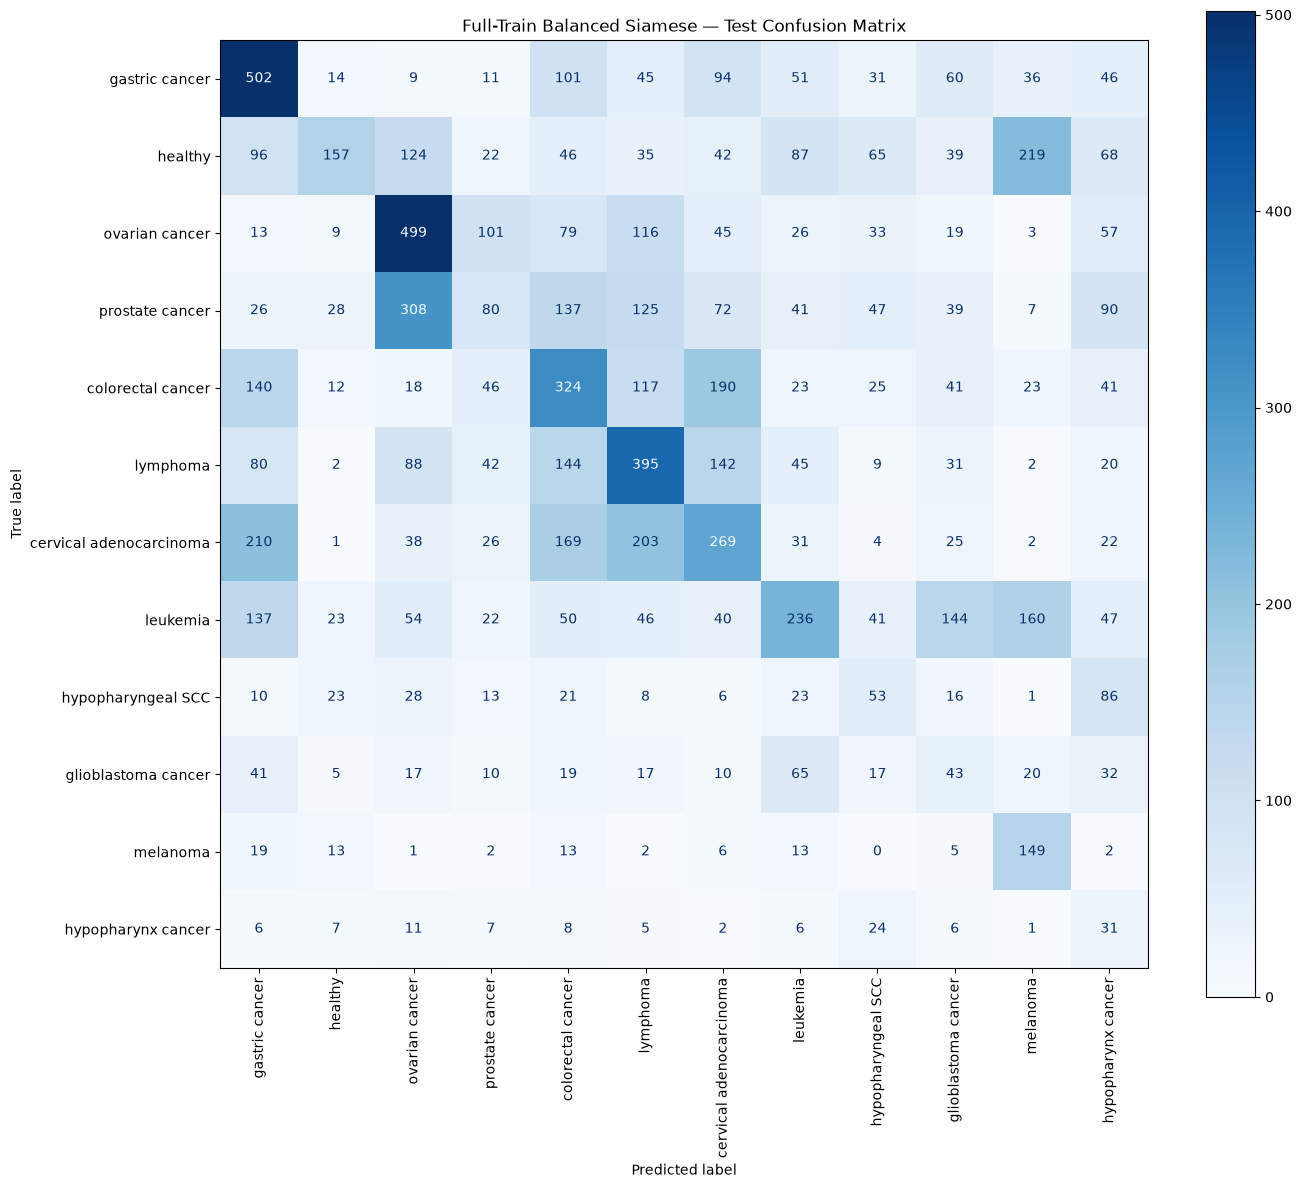

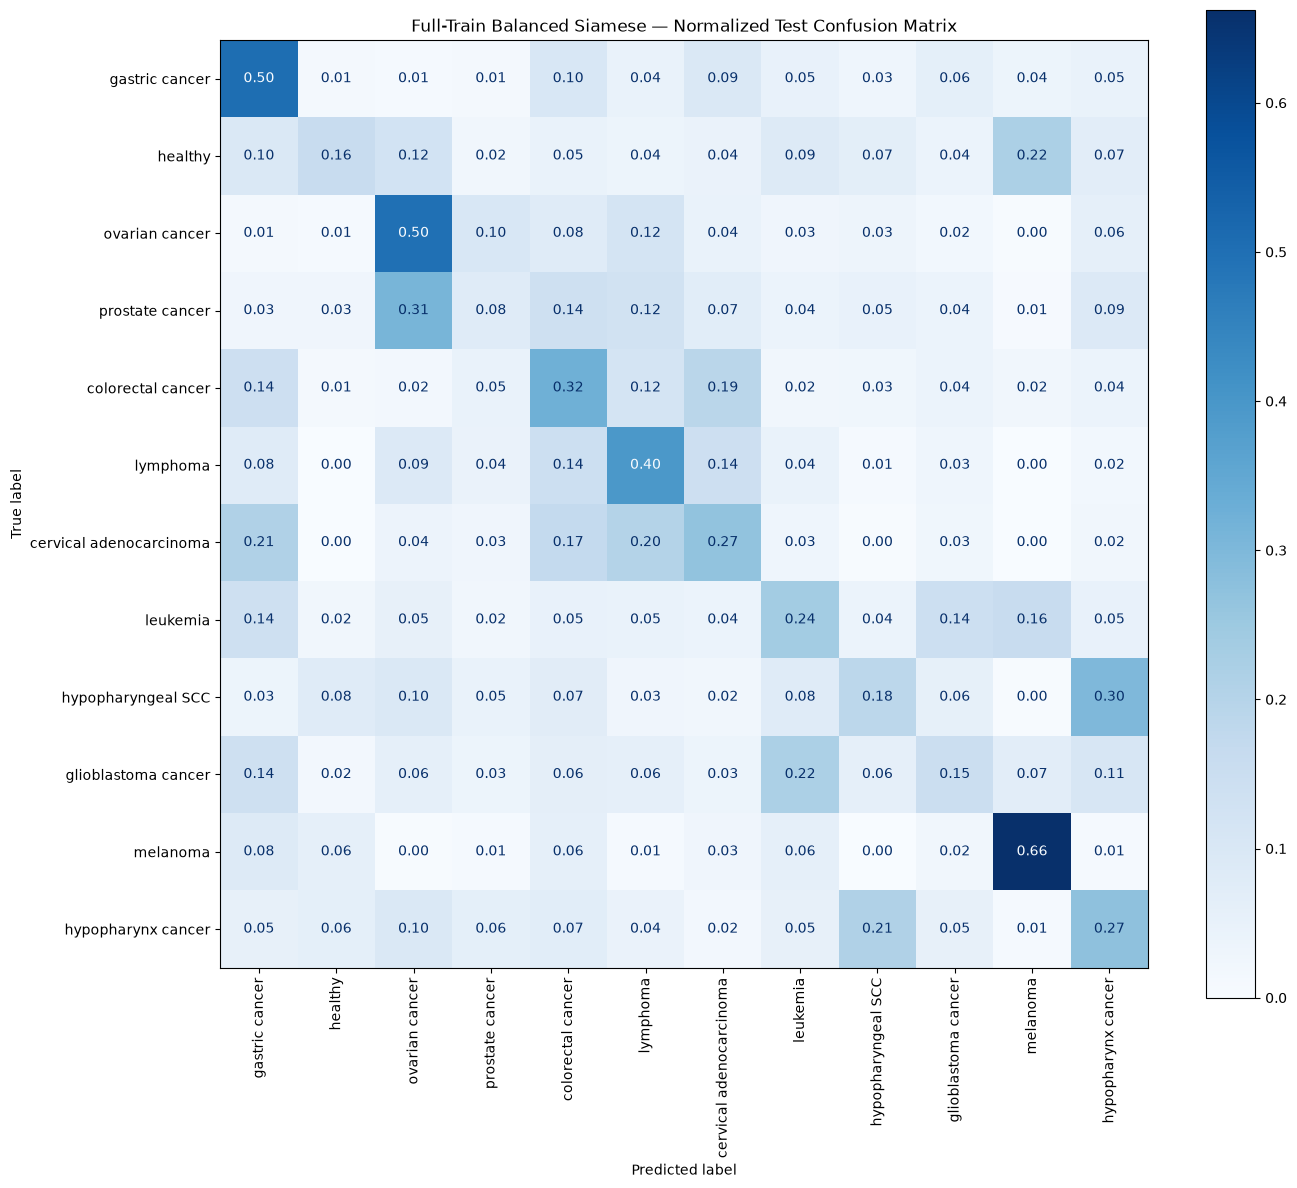

In [40]:
# ============================================================
# CELL 34 — FULL CONFUSION MATRICES
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay


labels_order = np.arange(N_CLASSES)

display_names = [
    class_names[i]
    for i in labels_order
]


# ------------------------------------------------------------
# COUNTS
# ------------------------------------------------------------

cm_counts = confusion_matrix(
    test_labels,
    test_top1_pred,
    labels=labels_order
)


fig, ax = plt.subplots(
    figsize=(14, 12)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_counts,
    display_labels=display_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True,
    values_format="d"
)

ax.set_title(
    "Full-Train Balanced Siamese — Test Confusion Matrix"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# NORMALIZED BY TRUE CLASS
# ------------------------------------------------------------

cm_normalized = confusion_matrix(
    test_labels,
    test_top1_pred,
    labels=labels_order,
    normalize="true"
)


fig, ax = plt.subplots(
    figsize=(14, 12)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=display_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True,
    values_format=".2f"
)

ax.set_title(
    "Full-Train Balanced Siamese — Normalized Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# CELL 35 — MAIN CLASS CONFUSIONS
# ============================================================

confusion_rows = []


for true_class in range(N_CLASSES):

    class_support = (
        cm_counts[
            true_class,
            :
        ].sum()
    )

    for predicted_class in range(
        N_CLASSES
    ):

        if (
            true_class
            ==
            predicted_class
        ):
            continue

        count = int(
            cm_counts[
                true_class,
                predicted_class
            ]
        )

        if count == 0:
            continue

        percentage = (
            count
            /
            class_support
        )

        confusion_rows.append({
            "true_class_id":
                true_class,

            "true_class":
                class_names[
                    true_class
                ],

            "predicted_class_id":
                predicted_class,

            "predicted_class":
                class_names[
                    predicted_class
                ],

            "count":
                count,

            "percentage_of_true_class":
                percentage
        })


confusions_df = pd.DataFrame(
    confusion_rows
)


confusions_df = (
    confusions_df
    .sort_values(
        "percentage_of_true_class",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 100)
print("TOP CLASS CONFUSIONS")
print("=" * 100)

print(
    confusions_df
    .head(30)
    .to_string(
        index=False,
        formatters={
            "percentage_of_true_class":
            lambda x: f"{x:.2%}"
        }
    )
)

TOP CLASS CONFUSIONS
 true_class_id              true_class  predicted_class_id         predicted_class  count percentage_of_true_class
             3         prostate cancer                   2          ovarian cancer    308                   30.80%
             8      hypopharyngeal SCC                  11      hypopharynx cancer     86                   29.86%
             9     glioblastoma cancer                   7                leukemia     65                   21.96%
             1                 healthy                  10                melanoma    219                   21.90%
            11      hypopharynx cancer                   8      hypopharyngeal SCC     24                   21.05%
             6 cervical adenocarcinoma                   0          gastric cancer    210                   21.00%
             6 cervical adenocarcinoma                   5                lymphoma    203                   20.30%
             4       colorectal cancer                   6 

In [42]:
# ============================================================
# CELL 36 — COMPLETE TEST CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

target_names = [
    class_names[i]
    for i in range(N_CLASSES)
]

report_text = classification_report(
    test_labels,
    test_top1_pred,
    labels=np.arange(N_CLASSES),
    target_names=target_names,
    digits=4,
    zero_division=0
)

print("=" * 100)
print("FULL-TRAIN BALANCED SIAMESE — TEST CLASSIFICATION REPORT")
print("=" * 100)
print(report_text)


report_dict = classification_report(
    test_labels,
    test_top1_pred,
    labels=np.arange(N_CLASSES),
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_df = (
    pd.DataFrame(report_dict)
    .T
)

report_df.to_csv(
    ARTIFACTS_DIR
    / "fulltrain_balanced_test_classification_report.csv"
)

print()
print("Classification report saved.")

FULL-TRAIN BALANCED SIAMESE — TEST CLASSIFICATION REPORT
                         precision    recall  f1-score   support

         gastric cancer     0.3922    0.5020    0.4404      1000
                healthy     0.5340    0.1570    0.2427      1000
         ovarian cancer     0.4176    0.4990    0.4547      1000
        prostate cancer     0.2094    0.0800    0.1158      1000
      colorectal cancer     0.2916    0.3240    0.3070      1000
               lymphoma     0.3546    0.3950    0.3737      1000
cervical adenocarcinoma     0.2930    0.2690    0.2805      1000
               leukemia     0.3648    0.2360    0.2866      1000
     hypopharyngeal SCC     0.1519    0.1840    0.1664       288
    glioblastoma cancer     0.0919    0.1453    0.1126       296
               melanoma     0.2392    0.6622    0.3514       225
     hypopharynx cancer     0.0572    0.2719    0.0945       114

               accuracy                         0.3068      8923
              macro avg     0.2

In [43]:
# ============================================================
# CELL 37 — MAIN CONFUSION FOR EACH TRUE CLASS
# ============================================================

main_confusions = []

for true_class in range(N_CLASSES):

    row = cm_counts[true_class].copy()

    support = row.sum()

    # Non consideriamo la predizione corretta
    row[true_class] = 0

    most_confused_with = int(
        np.argmax(row)
    )

    count = int(
        row[most_confused_with]
    )

    percentage = (
        count / support
        if support > 0
        else np.nan
    )

    main_confusions.append({
        "true_class":
            class_names[true_class],

        "main_confused_with":
            class_names[
                most_confused_with
            ],

        "count":
            count,

        "percentage_of_true_class":
            percentage
    })


main_confusions_df = pd.DataFrame(
    main_confusions
)


print("=" * 100)
print("MAIN CONFUSION FOR EACH CLASS")
print("=" * 100)

print(
    main_confusions_df
    .to_string(
        index=False,
        formatters={
            "percentage_of_true_class":
            lambda x: f"{x:.2%}"
        }
    )
)

MAIN CONFUSION FOR EACH CLASS
             true_class      main_confused_with  count percentage_of_true_class
         gastric cancer       colorectal cancer    101                   10.10%
                healthy                melanoma    219                   21.90%
         ovarian cancer                lymphoma    116                   11.60%
        prostate cancer          ovarian cancer    308                   30.80%
      colorectal cancer cervical adenocarcinoma    190                   19.00%
               lymphoma       colorectal cancer    144                   14.40%
cervical adenocarcinoma          gastric cancer    210                   21.00%
               leukemia                melanoma    160                   16.00%
     hypopharyngeal SCC      hypopharynx cancer     86                   29.86%
    glioblastoma cancer                leukemia     65                   21.96%
               melanoma          gastric cancer     19                    8.44%
     hypop

In [44]:
# ============================================================
# CELL 38 — FINAL SUMMARY — FULL-TRAIN BALANCED SIAMESE
# ============================================================

final_fulltrain_summary = pd.DataFrame(
    {
        "metric": [
            "train_samples",
            "best_semihard_epoch",
            "val_pairwise_auc",
            "val_top1",
            "val_macro_f1",
            "val_balanced_accuracy",
            "val_top3",
            "val_top5",
            "val_balanced_top3",
            "val_balanced_top5",
            "test_top1",
            "test_macro_f1",
            "test_balanced_accuracy",
            "test_top3",
            "test_top5",
            "test_balanced_top3",
            "test_balanced_top5"
        ],

        "value": [
            len(train_metadata),
            best_checkpoint["epoch"],
            best_pairwise_metrics["auc"],

            top1_accuracy,
            macro_f1,
            balanced_acc,
            top3_accuracy,
            top5_accuracy,
            val_bal_top3,
            val_bal_top5,

            test_top1,
            test_macro_f1,
            test_balanced_acc,
            test_top3,
            test_top5,
            test_bal_top3,
            test_bal_top5
        ]
    }
)


print("=" * 80)
print("FINAL FULL-TRAIN BALANCED SIAMESE SUMMARY")
print("=" * 80)

print(
    final_fulltrain_summary.to_string(
        index=False
    )
)


final_fulltrain_summary.to_csv(
    ARTIFACTS_DIR
    / "fulltrain_balanced_final_summary.csv",
    index=False
)

confusions_df.to_csv(
    ARTIFACTS_DIR
    / "fulltrain_balanced_test_confusions.csv",
    index=False
)

test_per_class_df.to_csv(
    ARTIFACTS_DIR
    / "fulltrain_balanced_test_per_class_topk.csv",
    index=False
)

print()
print("Artifacts saved in:")
print(ARTIFACTS_DIR)

FINAL FULL-TRAIN BALANCED SIAMESE SUMMARY
                metric        value
         train_samples 96167.000000
   best_semihard_epoch    13.000000
      val_pairwise_auc     0.670110
              val_top1     0.312109
          val_macro_f1     0.290417
 val_balanced_accuracy     0.319291
              val_top3     0.661848
              val_top5     0.830821
     val_balanced_top3     0.661931
     val_balanced_top5     0.827759
             test_top1     0.306847
         test_macro_f1     0.268841
test_balanced_accuracy     0.310454
             test_top3     0.664799
             test_top5     0.833352
    test_balanced_top3     0.658991
    test_balanced_top5     0.825019

Artifacts saved in:
D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_fulltrain_balanced
